In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.lines as mlines

# ============================================================
# 1) CONFIG
# ============================================================
FILE_PATH = "../../data_results/2_results/2-6_gpp_pos_partition/GPP_POS_ECUP_LCUP_summary_ecosystem.xlsx"


YEAR_MIN = 2016
CO2_COL = "co2"
X_COL = "temp_mean_anom"

COLOR_ECUP = "#2E8B57"
COLOR_LCUP = "#C96A23"
COLOR_RATE = "#F39C34"
COLOR_TIME = "#7B68B3"

X_TICKS = [2.5, 5.0, 7.5, 10.0, 12.5]

XLAB = "Annual mean temperature (°C)"
YLAB_GPP = "GPP (g C m$^{-2}$ yr$^{-1}$)"
YLAB_BAR = "Relative contribution (%)"

GPP_YLIM = {
    0: (-380, 610),
    500: (-380, 610),
}

COMP_YLIM = {
    ("ECUP", 0): (-420, 490),
    ("LCUP", 0): (-420, 490),
    ("ECUP", 500): (-300, 490),
    ("LCUP", 500): (-300, 490),
}

STAT_POS_GPP = {
    0: [(0.03, 0.08), (0.03, 0.01)],
    500: [(0.03, 0.08), (0.03, 0.01)],
}

STAT_POS_COMP = {
    ("ECUP", 0): [(0.03, 0.08), (0.03, 0.01)],
    ("LCUP", 0): [(0.03, 0.08), (0.03, 0.01)],
    ("ECUP", 500): [(0.03, 0.08), (0.03, 0.01)],
    ("LCUP", 500): [(0.03, 0.08), (0.03, 0.01)],
}


# ============================================================
# 2) HELPERS
# ============================================================
def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


def style_ax(ax, labelsize=15):
    ax.tick_params(
        axis="both", which="major",
        labelsize=labelsize,
        length=5,
        width=1.2,
        direction="out",
        bottom=True,
        left=True
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)


def fit_ols(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return {"slope": np.nan, "r2": np.nan, "p": np.nan}

    model = sm.OLS(y, sm.add_constant(x)).fit()

    return {
        "slope": float(model.params[1]),
        "r2": float(model.rsquared),
        "p": float(model.pvalues[1]),
    }


def format_reg_text(stats):
    stars = p_to_stars(stats["p"])

    slope_txt = "Slope = NA" if pd.isna(stats["slope"]) else f"Slope = {stats['slope']:.1f}"

    if pd.isna(stats["r2"]) or stats["r2"] < 0.01:
        r2_txt = r"$R^2$ < 0.01"
    else:
        r2_txt = rf"$R^2$ = {stats['r2']:.2f}{stars}"

    return f"{slope_txt}, {r2_txt}"


def draw_reg(ax, x, y, color, label=None):
    stats = fit_ols(x, y)

    linestyle = "-" if (not pd.isna(stats["p"]) and stats["p"] < 0.05) else "--"

    sns.regplot(
        x=x,
        y=y,
        ax=ax,
        ci=95,
        color=color,
        scatter_kws={"s": 60, "alpha": 0.70},
        line_kws={"lw": 3.5, "linestyle": linestyle},
        label=label
    )

    return stats


def log_mean(x1, x0, tol=1e-12):
    if (x1 <= 0) or (x0 <= 0):
        return np.nan

    if abs(x1 - x0) < tol:
        return x1

    return (x1 - x0) / (np.log(x1) - np.log(x0))


def lmdi(g1, g0, r1, r0, t1, t0):
    vals = [g1, g0, r1, r0, t1, t0]

    if any([(pd.isna(v) or v <= 0) for v in vals]):
        return np.nan, np.nan

    L = log_mean(g1, g0)

    d_rate = L * np.log(r1 / r0)
    d_time = L * np.log(t1 / t0)

    return d_rate, d_time


# ============================================================
# 3) READ DATA
# ============================================================
df = pd.read_excel(FILE_PATH)
df = df[df["year"] > YEAR_MIN].copy()

required_cols = [
    CO2_COL, X_COL,
    "GPP_ecup", "GPP_lcup",
    "GPP_ecup_base", "GPP_lcup_base",
    "GPP_ecup_anom", "GPP_lcup_anom",
    "GPP_rate_ecup", "GPP_rate_lcup",
    "GPP_rate_ecup_base", "GPP_rate_lcup_base",
    "ECUP", "LCUP",
    "ECUP_base", "LCUP_base",
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing columns in input file: {missing_cols}")


# ============================================================
# 4) LMDI COMPONENTS
# ============================================================
ecup_rate_list = []
ecup_time_list = []
lcup_rate_list = []
lcup_time_list = []

for _, row in df.iterrows():
    d_rate, d_time = lmdi(
        row["GPP_ecup"],
        row["GPP_ecup_base"],
        row["GPP_rate_ecup"],
        row["GPP_rate_ecup_base"],
        row["ECUP"],
        row["ECUP_base"],
    )
    ecup_rate_list.append(d_rate)
    ecup_time_list.append(d_time)

    d_rate, d_time = lmdi(
        row["GPP_lcup"],
        row["GPP_lcup_base"],
        row["GPP_rate_lcup"],
        row["GPP_rate_lcup_base"],
        row["LCUP"],
        row["LCUP_base"],
    )
    lcup_rate_list.append(d_rate)
    lcup_time_list.append(d_time)

df["dGPP_total"] = df["GPP_ecup_anom"] + df["GPP_lcup_anom"]

df["dGPP_ecup"] = df["GPP_ecup"] - df["GPP_ecup_base"]
df["dGPP_lcup"] = df["GPP_lcup"] - df["GPP_lcup_base"]

df["dGPP_ecup_rate"] = ecup_rate_list
df["dGPP_ecup_time"] = ecup_time_list
df["dGPP_lcup_rate"] = lcup_rate_list
df["dGPP_lcup_time"] = lcup_time_list


# ============================================================
# 5) SIGNED CONTRIBUTION DIRECTLY TO TOTAL GPP
# ============================================================
rows_bar = []

for co2v, dfi in df.groupby(CO2_COL):
    dGPP_total = dfi["dGPP_total"]
    denom = np.abs(dGPP_total).sum()

    if denom == 0:
        row = {
            "co2": co2v,
            "ECUP_total": np.nan,
            "LCUP_total": np.nan,
            "ECUP_rate": np.nan,
            "ECUP_time": np.nan,
            "LCUP_rate": np.nan,
            "LCUP_time": np.nan,
        }
    else:
        sgn_total = np.sign(dGPP_total)

        row = {
            "co2": co2v,

            "ECUP_total": (dfi["GPP_ecup_anom"] * sgn_total).sum() / denom * 100,
            "LCUP_total": (dfi["GPP_lcup_anom"] * sgn_total).sum() / denom * 100,

            "ECUP_rate": (dfi["dGPP_ecup_rate"] * sgn_total).sum() / denom * 100,
            "ECUP_time": (dfi["dGPP_ecup_time"] * sgn_total).sum() / denom * 100,

            "LCUP_rate": (dfi["dGPP_lcup_rate"] * sgn_total).sum() / denom * 100,
            "LCUP_time": (dfi["dGPP_lcup_time"] * sgn_total).sum() / denom * 100,
        }

    rows_bar.append(row)

df_bar_signed = pd.DataFrame(rows_bar)

print("\nSigned contribution directly to total GPP:")
print(df_bar_signed)

d_amb = df[df[CO2_COL] == 0].copy()
d_ele = df[df[CO2_COL] == 500].copy()


# ============================================================
# 6) PLOT FUNCTIONS
# ============================================================
def plot_total_gpp_panel(ax, d, co2v, panel_label):
    x = d[X_COL].to_numpy(float)

    y_ecup = d["GPP_ecup_anom"].to_numpy(float)
    y_lcup = d["GPP_lcup_anom"].to_numpy(float)

    res_ecup = draw_reg(ax, x, y_ecup, COLOR_ECUP, label="ECUP")
    res_lcup = draw_reg(ax, x, y_lcup, COLOR_LCUP, label="LCUP")

    ax.text(
        *STAT_POS_GPP[co2v][0],
        format_reg_text(res_ecup),
        transform=ax.transAxes,
        color=COLOR_ECUP,
        fontsize=14,
        ha="left",
        va="bottom"
    )

    ax.text(
        *STAT_POS_GPP[co2v][1],
        format_reg_text(res_lcup),
        transform=ax.transAxes,
        color=COLOR_LCUP,
        fontsize=14,
        ha="left",
        va="bottom"
    )

    ax.axhline(0, color="gray", lw=1.1, ls="--", alpha=0.8)

    ax.text(
        0.02,
        0.98,
        panel_label,
        transform=ax.transAxes,
        fontsize=20,
        va="top",
        ha="left"
    )

    ax.set_xlabel(XLAB, fontsize=20)
    ax.set_ylabel(YLAB_GPP, fontsize=20)
    ax.set_ylim(GPP_YLIM[co2v])
    ax.set_xticks(X_TICKS)
    ax.set_xticklabels(X_TICKS)

    style_ax(ax, labelsize=18)


def plot_component_panel(ax, d, stage, co2v, panel_label):
    x = d[X_COL].to_numpy(float)

    if stage == "ECUP":
        rate_col = "dGPP_ecup_rate"
        time_col = "dGPP_ecup_time"
    elif stage == "LCUP":
        rate_col = "dGPP_lcup_rate"
        time_col = "dGPP_lcup_time"
    else:
        raise ValueError("stage must be 'ECUP' or 'LCUP'")

    res_rate = draw_reg(
        ax,
        x,
        d[rate_col].to_numpy(float),
        COLOR_RATE,
        label="GPP$_{rate}$"
    )

    res_time = draw_reg(
        ax,
        x,
        d[time_col].to_numpy(float),
        COLOR_TIME,
        label="CUP"
    )

    ax.text(
        *STAT_POS_COMP[(stage, co2v)][0],
        format_reg_text(res_rate),
        transform=ax.transAxes,
        color=COLOR_RATE,
        fontsize=13,
        ha="left",
        va="bottom"
    )

    ax.text(
        *STAT_POS_COMP[(stage, co2v)][1],
        format_reg_text(res_time),
        transform=ax.transAxes,
        color=COLOR_TIME,
        fontsize=13,
        ha="left",
        va="bottom"
    )

    ax.axhline(0, color="gray", lw=1.1, ls="--", alpha=0.8)

    ax.text(
        0.02,
        0.98,
        panel_label,
        transform=ax.transAxes,
        fontsize=18,
        va="top",
        ha="left"
    )

    ax.set_xlabel(XLAB, fontsize=17)
    ax.set_ylabel(YLAB_GPP, fontsize=17)
    ax.set_ylim(COMP_YLIM[(stage, co2v)])
    ax.set_xticks(X_TICKS)
    ax.set_xticklabels(X_TICKS)

    style_ax(ax, labelsize=15)


def plot_integrated_bar_panel(ax, df_bar, co2v, panel_label, ylim=(-20, 120)):
    row = df_bar[df_bar["co2"] == co2v].iloc[0]

    group_centers = np.array([0, 1.35, 2.70])
    width = 0.28

    # Group 1: stage contribution
    ax.bar(
        group_centers[0] - width / 2,
        row["ECUP_total"],
        width,
        color=COLOR_ECUP,
        edgecolor="black",
        linewidth=1.1,
        label="ECUP"
    )

    ax.bar(
        group_centers[0] + width / 2,
        row["LCUP_total"],
        width,
        color=COLOR_LCUP,
        edgecolor="black",
        linewidth=1.1,
        label="LCUP"
    )

    # Group 2: ECUP source
    ax.bar(
        group_centers[1] - width / 2,
        row["ECUP_rate"],
        width,
        color=COLOR_RATE,
        edgecolor="black",
        linewidth=1.1,
        label="GPP$_{rate}$"
    )

    ax.bar(
        group_centers[1] + width / 2,
        row["ECUP_time"],
        width,
        color=COLOR_TIME,
        edgecolor="black",
        linewidth=1.1,
        label="CUP"
    )

    # Group 3: LCUP source
    ax.bar(
        group_centers[2] - width / 2,
        row["LCUP_rate"],
        width,
        color=COLOR_RATE,
        edgecolor="black",
        linewidth=1.1
    )

    ax.bar(
        group_centers[2] + width / 2,
        row["LCUP_time"],
        width,
        color=COLOR_TIME,
        edgecolor="black",
        linewidth=1.1
    )

    ax.axhline(0, color="k", lw=1)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        ["Stage\ncontribution", "ECUP\nsource", "LCUP\nsource"],
        fontsize=14
    )

    ax.set_ylabel(YLAB_BAR, fontsize=16)
    ax.set_ylim(ylim)

    ax.text(
        0.02,
        0.98,
        panel_label,
        transform=ax.transAxes,
        fontsize=18,
        va="top",
        ha="left"
    )

    style_ax(ax, labelsize=14)


# # ============================================================
# # 7A) FIGURE 1: INTEGRATED BAR PANELS
# # ============================================================
# fig1, axes_bar = plt.subplots(
#     1,
#     2,
#     figsize=(13, 5),
#     sharey=True
# )

# plot_integrated_bar_panel(
#     axes_bar[0],
#     df_bar_signed,
#     0,
#     "(a) Ambient CO$_2$",
#     ylim=(-40, 120)
# )

# plot_integrated_bar_panel(
#     axes_bar[1],
#     df_bar_signed,
#     500,
#     "(b) Elevated CO$_2$",
#     ylim=(-40, 120)
# )

# handles, labels = axes_bar[1].get_legend_handles_labels()
# by_label = dict(zip(labels, handles))

# axes_bar[1].legend(
#     by_label.values(),
#     by_label.keys(),
#     loc="upper right",
#     fontsize=12,
#     frameon=True
# )

# fig1.align_ylabels()
# plt.subplots_adjust(wspace=0.25, bottom=0.18, top=0.92)
# plt.show()


# # ============================================================
# # 7B) FIGURE 2: TOTAL ECUP / LCUP RESPONSE
# # ============================================================
# fig2, axes_total = plt.subplots(
#     1,
#     2,
#     figsize=(11, 4.5),
#     sharey=True
# )

# plot_total_gpp_panel(
#     axes_total[0],
#     d_amb,
#     0,
#     "(a) Ambient CO$_2$"
# )

# plot_total_gpp_panel(
#     axes_total[1],
#     d_ele,
#     500,
#     "(b) Elevated CO$_2$"
# )

# legend_stage = [
#     mlines.Line2D([], [], color=COLOR_ECUP, marker="o",
#                   linestyle="-", markersize=8, label="ECUP"),
#     mlines.Line2D([], [], color=COLOR_LCUP, marker="o",
#                   linestyle="-", markersize=8, label="LCUP"),
# ]

# axes_total[0].legend(
#     handles=legend_stage,
#     loc="upper right",
#     fontsize=12,
#     frameon=True
# )

# fig2.align_ylabels()
# plt.subplots_adjust(wspace=0.25, bottom=0.18, top=0.92)
# plt.show()


# # ============================================================
# # 7C) FIGURE 3: COMPONENT DECOMPOSITION
# # ============================================================
# fig3, axes_comp = plt.subplots(
#     2,
#     2,
#     figsize=(11, 8),
#     sharex=False,
#     sharey=False
# )

# plot_component_panel(
#     axes_comp[0, 0],
#     d_amb,
#     "ECUP",
#     0,
#     "(a) ECUP · Ambient CO$_2$"
# )

# plot_component_panel(
#     axes_comp[0, 1],
#     d_amb,
#     "LCUP",
#     0,
#     "(b) LCUP · Ambient CO$_2$"
# )

# plot_component_panel(
#     axes_comp[1, 0],
#     d_ele,
#     "ECUP",
#     500,
#     "(c) ECUP · Elevated CO$_2$"
# )

# plot_component_panel(
#     axes_comp[1, 1],
#     d_ele,
#     "LCUP",
#     500,
#     "(d) LCUP · Elevated CO$_2$"
# )

# legend_comp = [
#     mlines.Line2D([], [], color=COLOR_RATE, marker="o",
#                   linestyle="-", markersize=8, label="GPP$_{rate}$"),
#     mlines.Line2D([], [], color=COLOR_TIME, marker="o",
#                   linestyle="-", markersize=8, label="CUP"),
# ]

# axes_comp[1, 0].legend(
#     handles=legend_comp,
#     loc="upper right",
#     fontsize=12,
#     frameon=True,
#     bbox_to_anchor=(0.43, 0.88)
# )

# fig3.align_ylabels()
# plt.subplots_adjust(wspace=0.30, hspace=0.30, bottom=0.10, top=0.94)
# plt.show()


Signed contribution directly to total GPP:
   co2  ECUP_total  LCUP_total  ECUP_rate  ECUP_time  LCUP_rate  LCUP_time
0    0   45.388733   54.611267  46.674544  -1.368830  45.165547   9.395201
1  500   55.714270   44.285730  19.562913  35.888917   5.850005  38.460434


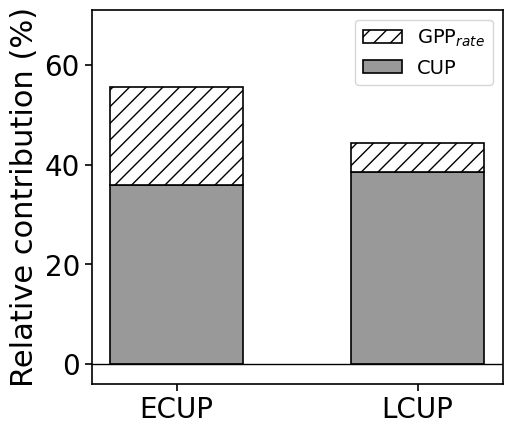

In [2]:
# ============================================================
# Elevated CO2 only: ECUP / LCUP component contribution
# CUP = gray
# GPP_rate = white with hatch
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Colors
# ============================================================
COLOR_CUP = "0.60"     # gray
COLOR_RATE = "white"  # white with hatch

# ============================================================
# Helper
# ============================================================
def style_ax(ax, labelsize=18):
    ax.tick_params(
        axis="both", which="major",
        labelsize=labelsize,
        length=5,
        width=1.2,
        direction="out",
        bottom=True,
        left=True
    )
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)


def plot_elevated_component_panel(
    ax,
    df_bar,
    co2v=500,
    panel_label="Elevated CO$_2$",
    ylim=(-4, 71)
):
    row = df_bar[df_bar["co2"] == co2v].iloc[0]

    x = np.array([0, 1])
    width = 0.55

    cup_vals = np.array(
        [row["ECUP_time"], row["LCUP_time"]],
        dtype=float
    )

    rate_vals = np.array(
        [row["ECUP_rate"], row["LCUP_rate"]],
        dtype=float
    )

    for i in range(len(x)):
        pos_base = 0.0
        neg_base = 0.0

        # --------------------------
        # CUP first: gray
        # --------------------------
        cup = cup_vals[i]

        if np.isfinite(cup):
            if cup >= 0:
                ax.bar(
                    x[i],
                    cup,
                    width=width,
                    bottom=pos_base,
                    color=COLOR_CUP,
                    edgecolor="black",
                    linewidth=1.2,
                    label="CUP" if i == 0 else None
                )
                pos_base += cup
            else:
                ax.bar(
                    x[i],
                    cup,
                    width=width,
                    bottom=neg_base,
                    color=COLOR_CUP,
                    edgecolor="black",
                    linewidth=1.2,
                    label="CUP" if i == 0 else None
                )
                neg_base += cup

        # --------------------------
        # GPP rate second: white + hatch
        # --------------------------
        rate = rate_vals[i]

        if np.isfinite(rate):
            if rate >= 0:
                ax.bar(
                    x[i],
                    rate,
                    width=width,
                    bottom=pos_base,
                    color=COLOR_RATE,
                    edgecolor="black",
                    linewidth=1.2,
                    hatch="//",
                    label="GPP$_{rate}$" if i == 0 else None
                )
                pos_base += rate
            else:
                ax.bar(
                    x[i],
                    rate,
                    width=width,
                    bottom=neg_base,
                    color=COLOR_RATE,
                    edgecolor="black",
                    linewidth=1.2,
                    hatch="//",
                    label="GPP$_{rate}$" if i == 0 else None
                )
                neg_base += rate

    ax.axhline(0, color="black", lw=1)

    ax.set_xticks(x)
    ax.set_xticklabels(["ECUP", "LCUP"], fontsize=20)

    ax.set_ylabel("Relative contribution (%)", fontsize=22)
    ax.set_ylim(ylim)

    # ax.text(
    #     0.02,
    #     0.98,
    #     panel_label,
    #     transform=ax.transAxes,
    #     fontsize=22,
    #     ha="left",
    #     va="top"
    # )

    style_ax(ax, labelsize=20)


# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(
    1,
    1,
    figsize=(5.2, 4.8)
)

plot_elevated_component_panel(
    ax,
    df_bar_signed,
    co2v=500,
    panel_label="Elevated CO$_2$",
    ylim=(-4, 71)
)

# ============================================================
# Legend
# ============================================================
handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))


ax.legend(
    # by_label.values(),
    # by_label.keys(),
    handles[::-1],
    labels[::-1],
    loc="upper right",
    fontsize=14,
    frameon=True
)

plt.subplots_adjust(
    bottom=0.16,
    top=0.94,
    left=0.18,
    right=0.97
)

# plt.savefig(
#     "Fig_eCO2_ECUP_LCUP_CUP_rate_contribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()